In [1]:
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Network_science/term_project')

In [4]:
sm = pd.read_csv('student_mat.csv', index_col=0)
sm.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
1,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
2,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
3,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
4,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
5,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
sm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher      649

In [5]:
# drop age
sm.drop('age', axis=1, inplace=True)

In [6]:
# sum g1, g2, g3
sm['grade'] = sm['G1'] + sm['G2'] + sm['G3']
sm.drop(['G1', 'G2', 'G3'], axis=1, inplace=True)

In [7]:
num_vars = sm.select_dtypes(include=np.int64).columns

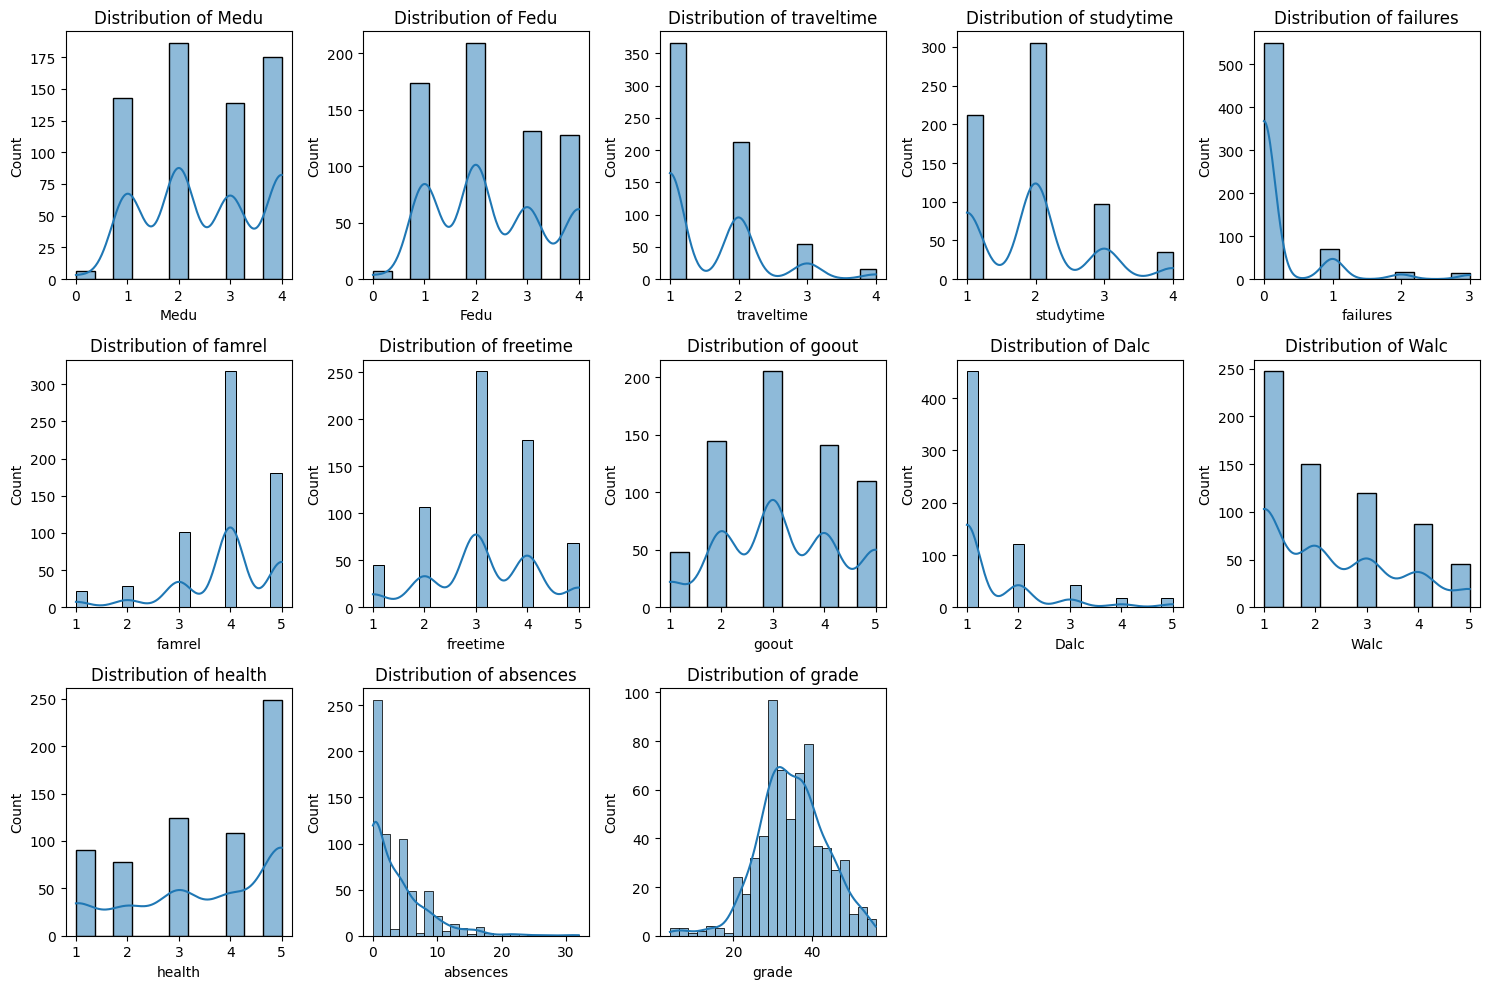

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_vars):
    plt.subplot(len(num_vars) // 5 + 1, 5, i + 1)
    sns.histplot(sm[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap of Numerical Variables')

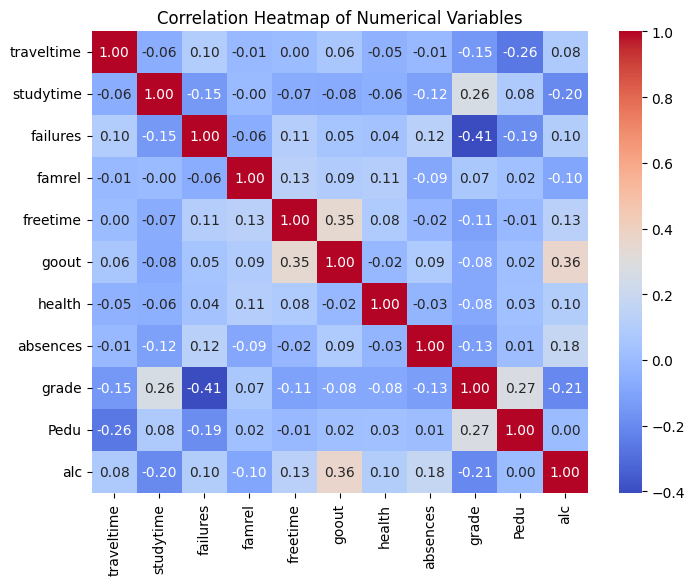

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(sm[num_vars].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Variables')

In [8]:
sm['Pedu'] = sm['Fedu'] + sm['Medu']
sm['alc'] = sm['Dalc'] + sm['Walc']
sm.drop(['Fedu', 'Medu', 'Dalc', 'Walc'], axis=1, inplace=True)

In [9]:
categorical_vars = sm.select_dtypes(include='object').columns

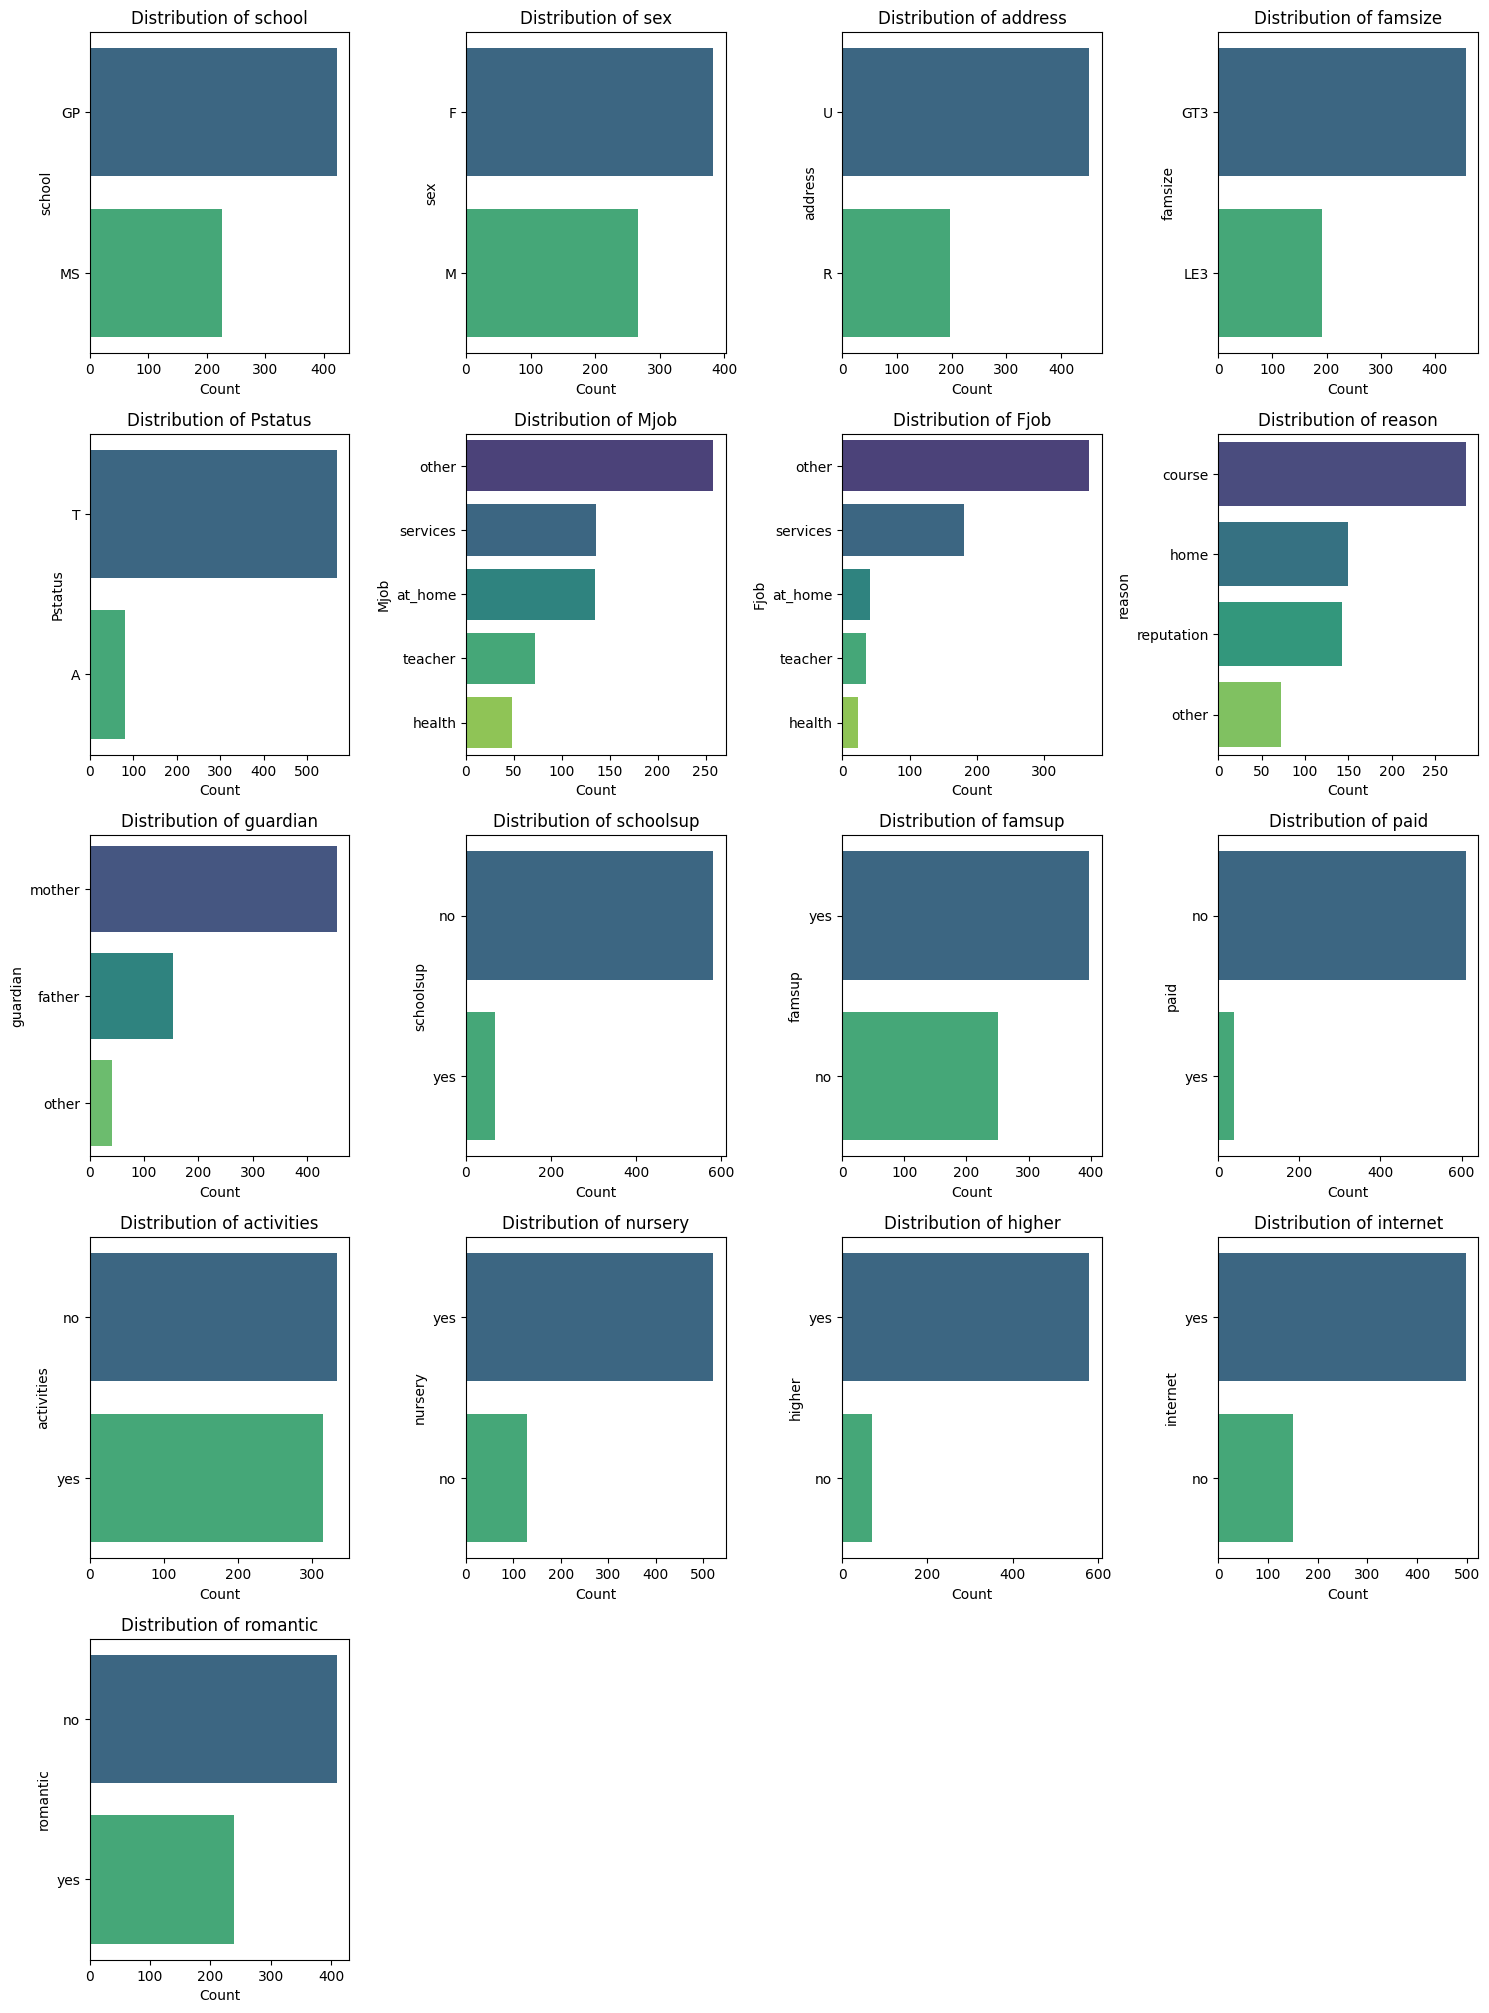

In [ ]:
plt.figure(figsize=(15, 4 * len(categorical_vars)))
for i, col in enumerate(categorical_vars):
    plt.subplot(len(categorical_vars), 4, i + 1)
    sns.countplot(y=sm[col], order=sm[col].value_counts().index, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

In [ ]:
len(sm.columns)

28

In [10]:
sm_encoded = pd.get_dummies(sm, columns=categorical_vars, drop_first=True)

X = sm_encoded.drop('grade', axis=1)
y = sm_encoded['grade']

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor = RandomForestRegressor(random_state=42)
rf_regressor.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
feature_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns)
sorted_feature_importances = feature_importances.sort_values(ascending=False)

print("Top 10 Feature Importances from Random Forest Regressor:")
print(sorted_feature_importances.head(10))

Top 10 Feature Importances from Random Forest Regressor:
failures      0.201882
alc           0.072380
Pedu          0.062799
absences      0.057720
goout         0.046625
higher_yes    0.046623
studytime     0.043657
school_MS     0.039420
freetime      0.039201
health        0.038142
dtype: float64


In [ ]:
!pip install shap

In [ ]:
import shap
explainer = shap.TreeExplainer(rf_regressor)
shap_values = explainer.shap_values(X)

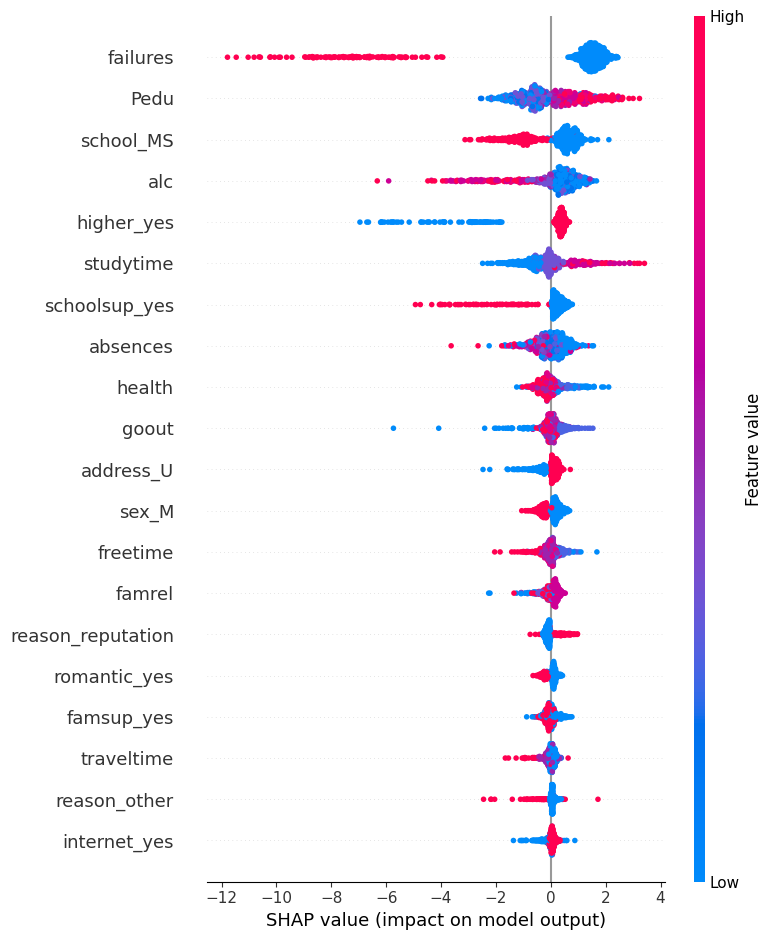

In [ ]:
shap.summary_plot(shap_values, X)

In [11]:
top_features = ['failures', 'alc', 'Pedu', 'absences', 'higher',
       'studytime', 'school', 'schoolsup', 'address', 'sex']

In [12]:
sm_top = sm[top_features]
sm_top['grade'] = sm['grade']

In [ ]:
sm_top.info()

<class 'pandas.core.frame.DataFrame'>
Index: 649 entries, 1 to 649
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   failures   649 non-null    int64 
 1   alc        649 non-null    int64 
 2   Pedu       649 non-null    int64 
 3   absences   649 non-null    int64 
 4   higher     649 non-null    object
 5   studytime  649 non-null    int64 
 6   school     649 non-null    object
 7   schoolsup  649 non-null    object
 8   address    649 non-null    object
 9   sex        649 non-null    object
 10  grade      649 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 60.8+ KB


In [13]:
lower_bound = sm_top['grade'].quantile(0.20)
upper_bound = sm_top['grade'].quantile(0.80)

bins = [sm_top['grade'].min() - 1, lower_bound, upper_bound, sm_top['grade'].max() + 1]
labels = ['low', 'mid', 'high']
sm_top['grade_group'] = pd.cut(sm_top['grade'], bins=bins, labels=labels, include_lowest=True, right=False)

In [14]:
bins_abs = [0, 5, np.inf]
labels_abs = ['normal', 'high']
sm_top['absences_group'] = pd.cut(sm_top['absences'], bins=bins_abs, labels=labels_abs, include_lowest=True, right=False)

In [15]:
sm_cat = sm_top.drop(['grade', 'absences'], axis=1)

In [16]:
!pip install causal-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 191.8/191.8 kB 5.0 MB/s eta 0:00:00


  0%|          | 0/11 [00:00<?, ?it/s]

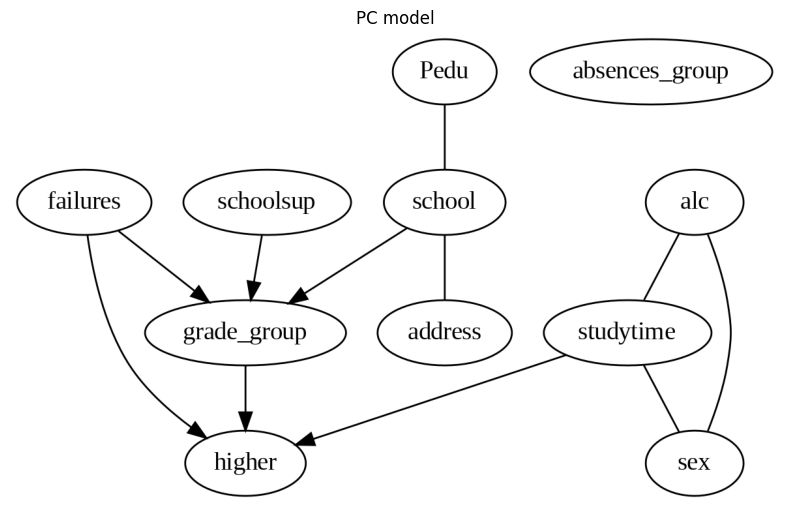

In [18]:
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import chisq

cg = pc(sm_cat.to_numpy(), 0.05, chisq, node_names=sm_cat.columns.tolist())
plt.figure(figsize=(8, 6))
plt.title("PC model")
cg.draw_pydot_graph()

In [19]:
# imposing some prior knowledge
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode
bk = BackgroundKnowledge()
bk.add_forbidden_by_node(GraphNode('failures'), GraphNode('grade_group'))
bk.add_forbidden_by_node(GraphNode('grade_group'), GraphNode('failures'))
bk.add_required_by_node(GraphNode('higher'), GraphNode('grade_group'))
bk.add_required_by_node(GraphNode('higher'), GraphNode('studytime'))
bk.add_required_by_node(GraphNode('address'), GraphNode('school'))

  0%|          | 0/11 [00:00<?, ?it/s]

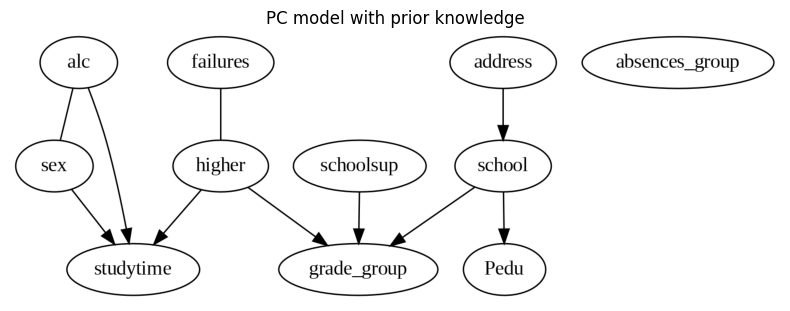

In [20]:
cg = pc(sm_cat.to_numpy(), 0.05, chisq, node_names=sm_cat.columns.tolist(), background_knowledge=bk)
plt.figure(figsize=(8, 6))
plt.title("PC model with prior knowledge")
cg.draw_pydot_graph()

In [21]:
# GES algorithm
from causallearn.search.ScoreBased.GES import ges
result = ges(sm_cat.to_numpy(), score_func='local_score_BDeu',
             node_names=sm_cat.columns.tolist())
cg_ges = result['G']

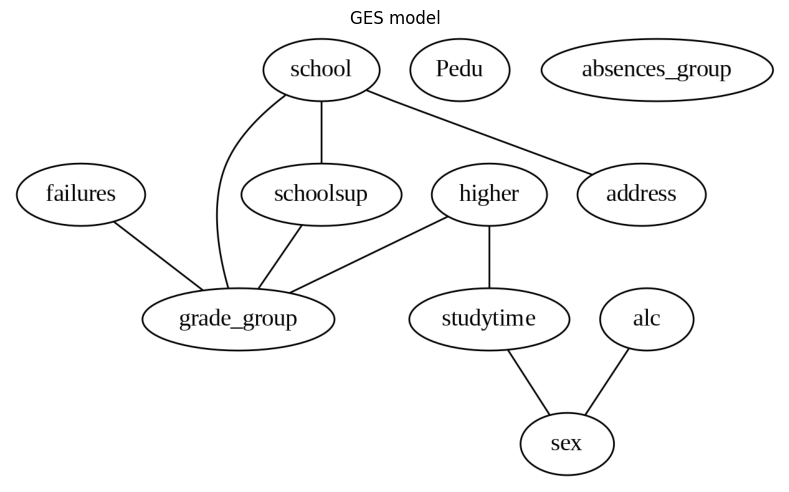

In [22]:
from causallearn.utils.GraphUtils import GraphUtils
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import io

pyd = GraphUtils.to_pydot(cg_ges)
tmp_png = pyd.create_png(f="png")
fp = io.BytesIO(tmp_png)
img = mpimg.imread(fp, format='png')
plt.figure(figsize=(8, 6))
plt.axis('off')
plt.title("GES model")
plt.imshow(img)

In [16]:
!pip install pgmpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 23.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 36.2 MB/s eta 0:00:00


In [ ]:
from itertools import combinations
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance_level = 0.05

column_names = sm_cat.columns.tolist()

p_value_matrix = pd.DataFrame(1.0, index=column_names, columns=column_names)

for col1, col2 in combinations(column_names, 2):
    chi2_stat, p_value, dof = chi_square(
        X=col1, Y=col2, Z=[],
        data=sm_cat,
        boolean=False,
        significance_level=significance_level
    )
    p_value_matrix.loc[col1, col2] = p_value

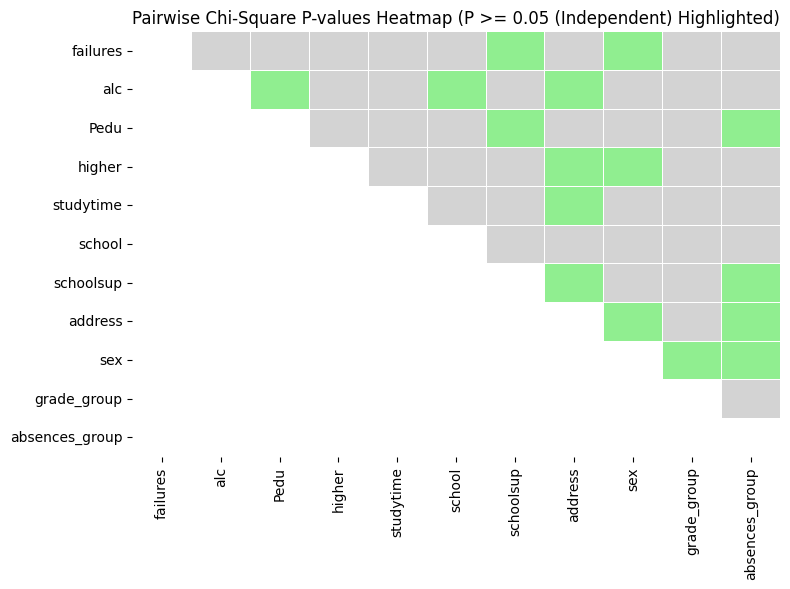

In [ ]:
import matplotlib.colors as mcolors

bounds = [p_value_matrix.min().min(), 0.05, p_value_matrix.max().max()]

colors = ['lightgray', 'lightgreen']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

mask = np.triu(np.ones_like(p_value_matrix, dtype=bool))
masked_p_value_matrix = p_value_matrix.mask(mask.transpose())

plt.figure(figsize=(8, 6))
sns.heatmap(masked_p_value_matrix, annot=False, cmap=cmap, fmt='.2e', linewidths=.5, cbar=False, norm=norm)
plt.title('Pairwise Chi-Square P-values Heatmap (P >= 0.05 (Independent) Highlighted)')
plt.show()

The below DAG is an outcome of multiple rounds of modifications based on the independence tests. pgmpy version 0.1.24 also included too man d-separations that are not the minimal set of d-separations, which makes the inspection difficult. I used the newer version 1.0.0 for this set of analysis.

In [17]:
from pgmpy.base import DAG

In [18]:
# initial DAG
dag = DAG([('absences_group','school'),
           ('absences_group','alc'),
           ('sex','alc'),
           ('alc','studytime'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','studytime'),
           ('schoolsup','grade_group'),
           ('address','school'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures')])

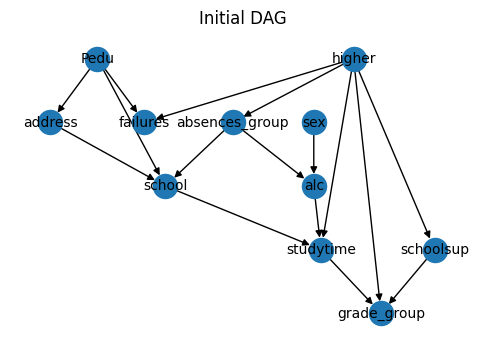

In [20]:
import networkx as nx
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(6, 4))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"), font_size=10)
plt.axis('off')
plt.title('Initial DAG')
plt.show()

In [21]:
# DAG after several rounds of modifications
dag = DAG([('absences_group','school'),
           ('absences_group','alc'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('alc','studytime'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','studytime'),
           ('schoolsup','grade_group'),
           ('address','school'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('failures','grade_group')])

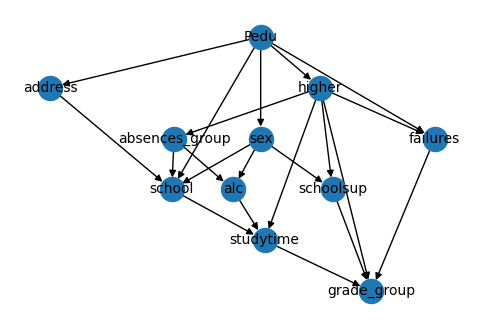

In [22]:
import networkx as nx
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(6, 4))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"), font_size=10)
plt.axis('off')
plt.show()

In [ ]:
dseps = dag.get_independencies()

In [ ]:
dseps

(sex ⟂ studytime | higher, alc, school)
(absences_group ⟂ schoolsup | higher)
(Pedu ⟂ grade_group | studytime, higher, failures, schoolsup)
(school ⟂ higher | absences_group, Pedu)
(failures ⟂ absences_group | higher)
(school ⟂ grade_group | Pedu, studytime, higher, schoolsup)
(alc ⟂ schoolsup | higher, sex)
(alc ⟂ Pedu | absences_group, sex)
(address ⟂ alc | absences_group, sex)
(address ⟂ studytime | higher, alc, school)
(failures ⟂ schoolsup | higher, sex)
(alc ⟂ grade_group | studytime, higher, failures, schoolsup)
(absences_group ⟂ grade_group | studytime, higher, failures, schoolsup)
(absences_group ⟂ studytime | higher, alc, school)
(studytime ⟂ schoolsup | higher, alc, school)
(address ⟂ grade_group | Pedu, studytime, higher, schoolsup)
(address ⟂ schoolsup | higher, sex)
(address ⟂ higher | Pedu)
(school ⟂ schoolsup | higher, sex)
(address ⟂ absences_group | higher)
(address ⟂ failures | Pedu)
(absences_group ⟂ Pedu | higher)
(failures ⟂ alc | absences_group, sex)
(Pedu ⟂ scho

In [ ]:
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=sm_cat,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
print("Assertions that are FALSE (i.e., data does NOT support independence):")
false_results = {assertion: is_independent for assertion, is_independent in results.items() if not is_independent}
pprint(false_results)

Assertions that are FALSE (i.e., data does NOT support independence):
{(school ⟂ grade_group | Pedu, studytime, higher, schoolsup): np.False_,
 (alc ⟂ schoolsup | higher, sex): np.False_}


In [23]:
# last modification
dag = DAG([('absences_group','school'),
           ('absences_group','alc'),
           ('sex','alc'),
           ('sex','school'),
           ('sex','schoolsup'),
           ('alc','studytime'),
           ('alc','schoolsup'),
           ('higher','studytime'),
           ('higher','absences_group'),
           ('higher','failures'),
           ('studytime', 'grade_group'),
           ('higher','grade_group'),
           ('higher','absences_group'),
           ('higher','schoolsup'),
           ('school','studytime'),
           ('school','grade_group'),
           ('schoolsup','grade_group'),
           ('address','school'),
           ('Pedu','address'),
           ('Pedu','school'),
           ('Pedu','failures'),
           ('Pedu','sex'),
           ('Pedu','higher'),
           ('failures','grade_group')])

In [ ]:
dseps = dag.get_independencies()

In [ ]:
from pgmpy.estimators.CITests import chi_square
from pgmpy.independencies import IndependenceAssertion

significance = 0.05
def test_dsep(dsep):
    test_outputs = []
    for X in list(dsep.get_assertion()[0]):
        for Y in list(dsep.get_assertion()[1]):
            Z = list(dsep.get_assertion()[2])
            test_result = chi_square(
                X=X, Y=Y, Z=Z,
                data=sm_cat,
                boolean=True,
                significance_level=significance
            )
            assertion = IndependenceAssertion(X, Y, Z)
            test_outputs.append((assertion, test_result))
    return test_outputs

results = [test_dsep(dsep) for dsep in dseps.get_assertions()]
results = dict([item for sublist in results for item in sublist])

In [ ]:
from pprint import pprint
print("Assertions that are FALSE (i.e., data does NOT support independence):")
false_results = {assertion: is_independent for assertion, is_independent in results.items() if not is_independent}
pprint(false_results)

Assertions that are FALSE (i.e., data does NOT support independence):
{}


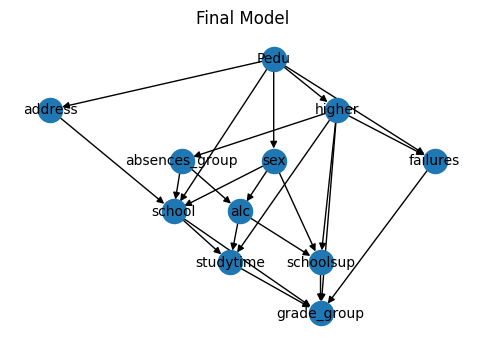

In [24]:
# final model
nx_graph = nx.DiGraph(dag.edges())

plt.figure(figsize=(6, 4))
nx.draw_networkx(nx_graph, with_labels=True, pos=nx.nx_pydot.pydot_layout(nx_graph, prog="dot"), font_size=10)
plt.title("Final Model")
plt.axis('off')
plt.show()